In [ ]:
# Importing relevant libraries

import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras as ks
import sklearn.preprocessing as sp
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import sklearn.model_selection as ms
import sklearn.metrics as metrics
import sklearn.svm as svm
import sklearn.neural_network as NN
from sklearn.cluster import KMeans

In [ ]:
crop_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Crop_recommendation.csv")
crop_data.head()

,N,P,K,temperature,humidity,ph,rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# **Question 2: Data Visualization and Preprocessing.**

In [ ]:
#Rename the columns of the dataset
crop_data.columns = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH', 'Rainfall', 'Crop']
crop_data.columns

Index(['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH',
       'Rainfall', 'Crop'],
      dtype='object')

In [ ]:
crop_data.shape

(2200, 8)

In [ ]:
crop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
# Checking how many classes does the data contain
print(len(crop_data['Crop'].unique()))
crop_data['Crop'].unique()

22


array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [ ]:
#Checking for missing values
crop_data.isnull().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH             0
Rainfall       0
Crop           0
dtype: int64

In [ ]:
#Check for Duplicate values
crop_data.duplicated().sum()

0

In [ ]:
#Summary statistics of Data
crop_data.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
#checking the number of occurence in each class
Class_distribution = crop_data['Crop'].value_counts()
Class_distribution

Crop
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [ ]:
Data_features = crop_data.drop(columns = ['Crop'])

### **Data Visualization**

<ipython-input-64-92f2a12f4b81>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Crop', data = crop_data, palette = 'deep')


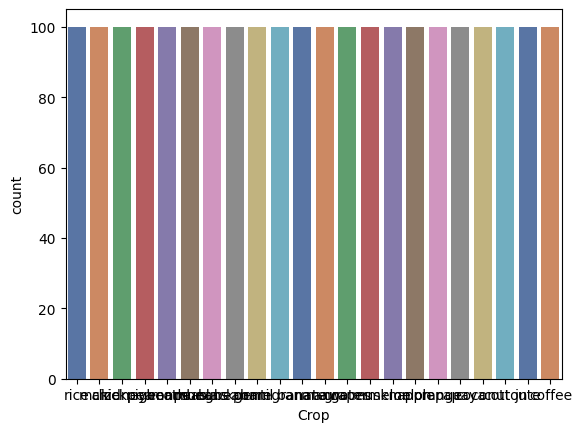

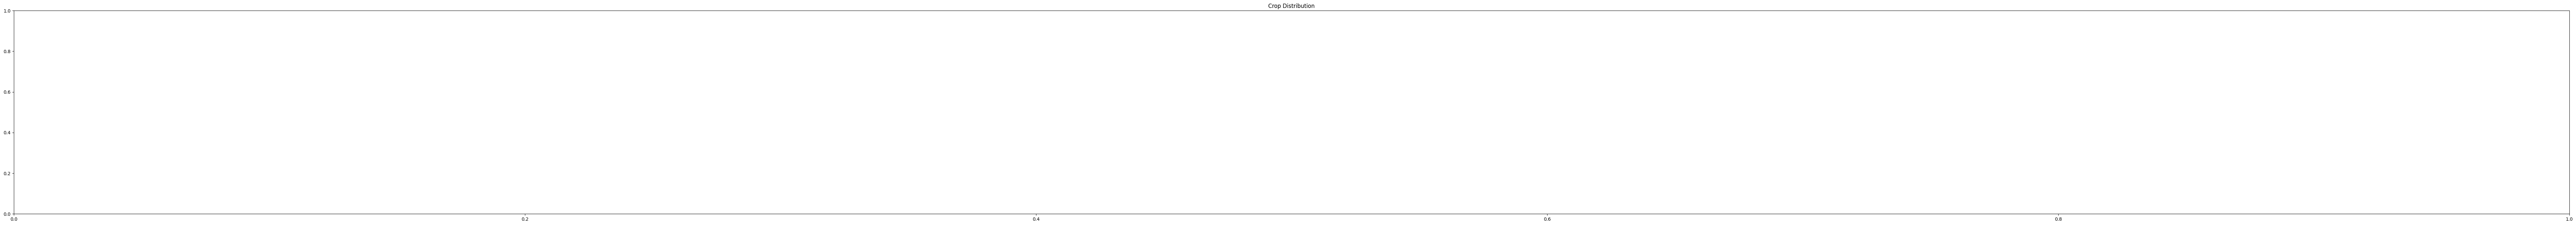

In [ ]:
#Plot showing the class distribution
sns.countplot(x = 'Crop', data = crop_data, palette = 'deep')
plt.title('Crop Distribution')
plt.show()

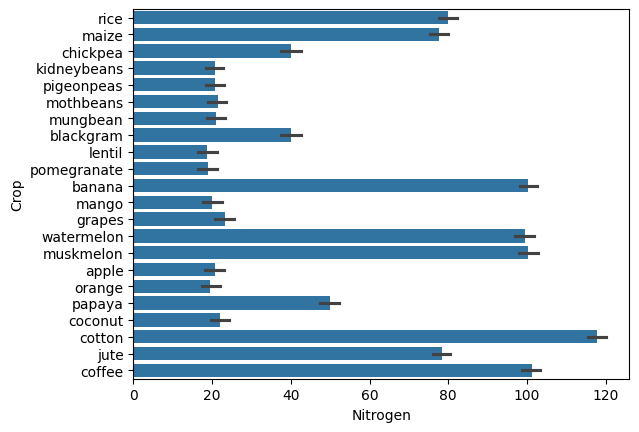

In [ ]:
sns.barplot(x = 'Nitrogen', y = 'Crop', data = crop_data)
plt.title('Crop vs Nitrogen')
plt.show()

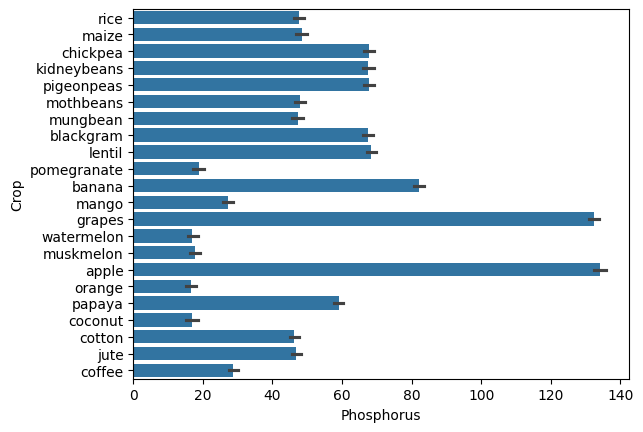

In [ ]:
sns.barplot(x = 'Phosphorus', y = 'Crop', data = crop_data)
plt.title('Crop vs Phosphorus')
plt.show()

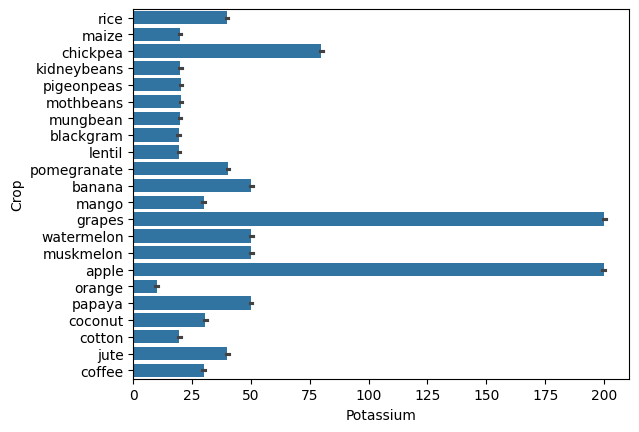

In [ ]:
sns.barplot(x = 'Potassium', y = 'Crop', data = crop_data)
plt.title('Crop vs Potassium')
plt.show()

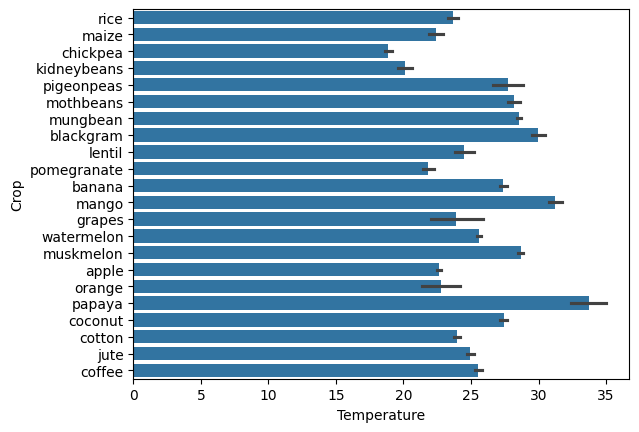

In [ ]:
sns.barplot(x = 'Temperature', y = 'Crop', data = crop_data)
plt.show()

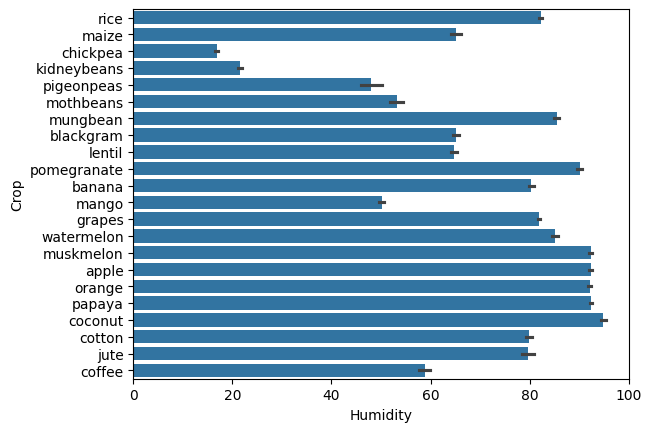

In [ ]:
sns.barplot(x = 'Humidity', y = 'Crop', data = crop_data)
plt.title('Crop vs Humidity')
plt.show()

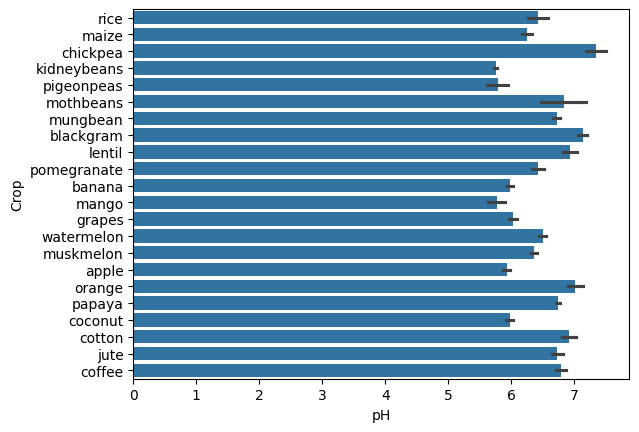

In [ ]:
sns.barplot(x = 'pH', y = 'Crop', data = crop_data)
plt.title('Crop vs pH value')
plt.show()

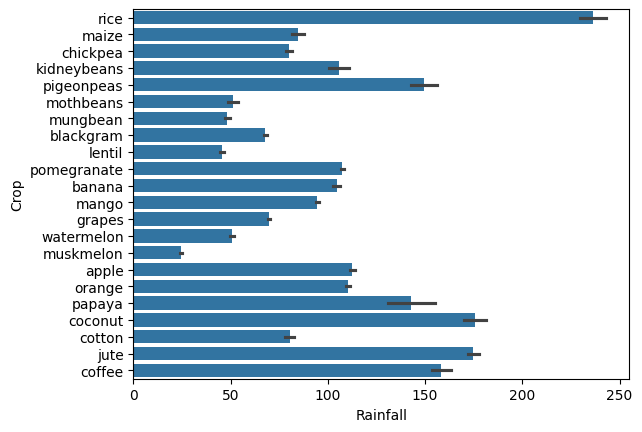

In [ ]:
sns.barplot(x = 'Rainfall', y = 'Crop', data = crop_data)
plt.title('Crop vs Rainfall')
plt.show()

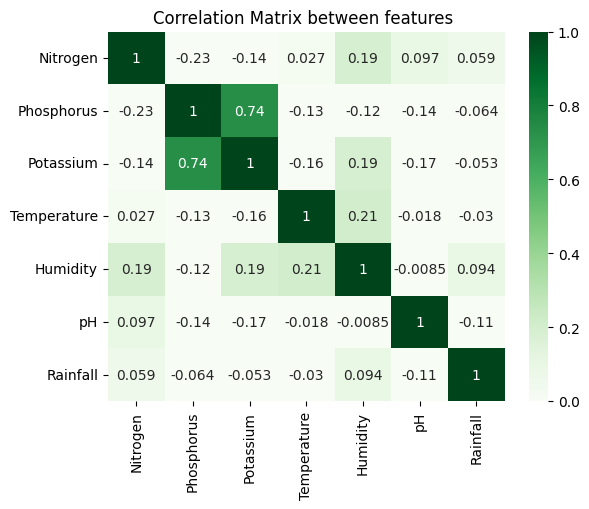

In [ ]:
sns.heatmap(Data_features.corr(), annot = True, vmin = 0, vmax = 1, cmap = 'Greens')
plt.title('Correlation Matrix between features ')
plt.show()

### **Data Encoding, Spliting, Scaling and Partitioning**

In [ ]:
# Changing the Class (Crop) to numeric variable for
encoder = LabelEncoder()
y_code = encoder.fit_transform(crop_data ['Crop'])

In [ ]:
crop_data.to_csv('Encoded_data.csv', index = False)
files.download('Encoded_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#The data is splitted into the target variable (y) and features (x)
x = crop_data.drop(columns=['Crop'])
y = y_code


In [ ]:
# Feature Scaling using Standardization
standard = sp.StandardScaler()
standard.fit(x)
X = standard.transform(x)

In [ ]:
# Data partitioning/Splitting
X_train, X_test, y_train, y_test = ms.train_test_split(X,y,test_size= 0.2, random_state= 40)

# **Question 3, Task 1: Implement a multiclass support vector machine using sci-kit-learn**

In [ ]:
# model development using the 3 SVC kernels
RBFSVM_model = svm.SVC(kernel = 'rbf', C = 1)
LinearSVM_model = svm.SVC(kernel = 'linear')
PolySVM_model = svm.SVC(kernel = 'poly', gamma = 1, C = 10)

In [ ]:
#SVM Model fitting
RBFSVM_model.fit(X_train, y_train)
LinearSVM_model.fit(X_train, y_train)
PolySVM_model.fit(X_train, y_train)

SVC(C=10, gamma=1, kernel='poly')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        19
           2       0.95      1.00      0.97        18
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        19
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        27
           7       1.00      1.00      1.00        18
           8       0.77      1.00      0.87        20
           9       0.95      1.00      0.98        20
          10       1.00      0.94      0.97        17
          11       1.00      1.00      1.00        19
          12       1.00      1.00      1.00        26
          13       1.00      1.00      1.00        14
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        25
          17       1.00    

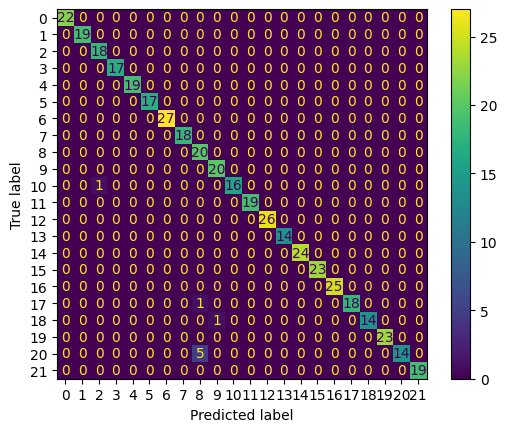

In [ ]:
#Radial Basic Function model prediction
RBFpred = RBFSVM_model.predict(X_test)

print(metrics.classification_report(y_test,RBFpred))

metrics.ConfusionMatrixDisplay.from_predictions(y_test,RBFpred)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        19
           2       0.95      1.00      0.97        18
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        19
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        27
           7       1.00      1.00      1.00        18
           8       0.83      1.00      0.91        20
           9       1.00      1.00      1.00        20
          10       1.00      0.94      0.97        17
          11       1.00      1.00      1.00        19
          12       1.00      1.00      1.00        26
          13       1.00      1.00      1.00        14
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        25
          17       1.00    

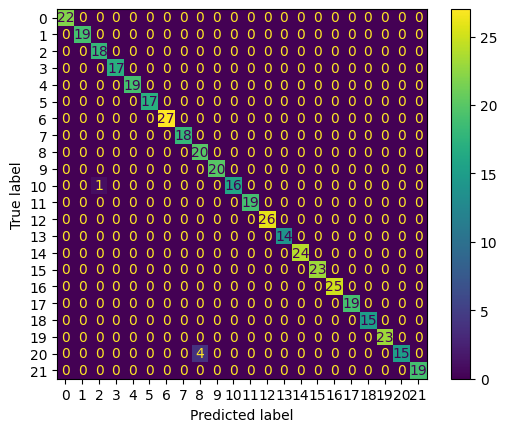

In [ ]:
Accuracy_ = []
model_name = []
#Linear model prediction
linearpred = LinearSVM_model.predict(X_test)

print(metrics.classification_report(y_test,linearpred))

metrics.ConfusionMatrixDisplay.from_predictions(y_test,linearpred)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        19
           2       0.95      1.00      0.97        18
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        19
           5       1.00      1.00      1.00        17
           6       1.00      0.96      0.98        27
           7       1.00      1.00      1.00        18
           8       0.80      1.00      0.89        20
           9       1.00      1.00      1.00        20
          10       1.00      0.94      0.97        17
          11       0.95      1.00      0.97        19
          12       1.00      1.00      1.00        26
          13       0.93      1.00      0.97        14
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        25
          17       1.00    

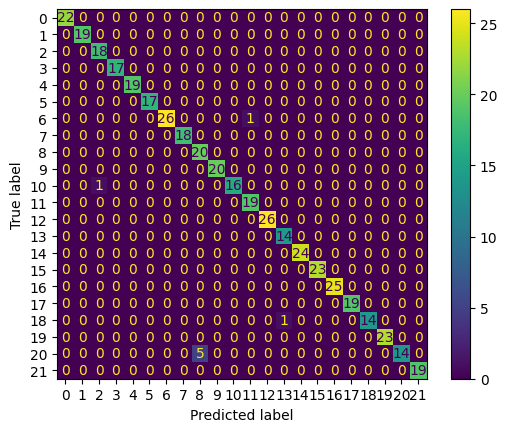

In [ ]:
# Polynomial model prediction and confusion matrix
Polypred = PolySVM_model.predict(X_test)

print(metrics.classification_report(y_test,Polypred))

metrics.ConfusionMatrixDisplay.from_predictions(y_test,Polypred)

The best parameter for implementing support vector machine is  {'C': 1, 'kernel': 'linear'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        19
           2       0.95      1.00      0.97        18
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        19
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        27
           7       1.00      1.00      1.00        18
           8       0.83      1.00      0.91        20
           9       1.00      1.00      1.00        20
          10       1.00      0.94      0.97        17
          11       1.00      1.00      1.00        19
          12       1.00      1.00      1.00        26
          13       1.00      1.00      1.00        14
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00

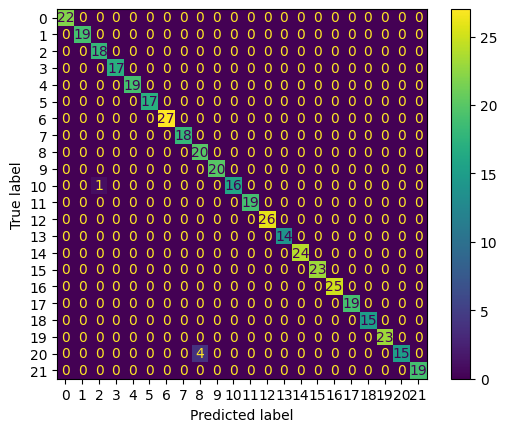

In [ ]:
#Checking for best Parameter using Grid Search
params = {'kernel': ['linear', 'rbf'],'C': [0.001, 0.01, 0.1, 1],}

model = svm.SVC()
GCV_SVmodel = ms.GridSearchCV(model, param_grid=params, cv=3, n_jobs = -1)
GCV_SVmodel.fit(X_train, y_train)

print("The best parameter for implementing support vector machine is ", GCV_SVmodel.best_params_)

GCV_y_SVpred = GCV_SVmodel.predict(X_test)

grid_accuracy = metrics.accuracy_score(y_test,GCV_y_SVpred)
Accuracy_.append(grid_accuracy)
model_name.append('SVM')

print(metrics.classification_report(y_test,GCV_y_SVpred))

metrics.ConfusionMatrixDisplay.from_predictions(y_test,GCV_y_SVpred)

### **Comparing the accuracy of the best SVM parameter with other supervised learning classifiers**

In [ ]:
#Evaluation of different classification models using cross validation
models = {"SVC": svm.SVC(kernel = 'linear'), "KNN" : KNeighborsClassifier(), "RandomForest" : RandomForestClassifier()}
results = []

In [ ]:
for model in models.values():
    kf = ms.KFold(n_splits = 3, random_state = 42, shuffle = True)

    cv_result = ms.cross_val_score(model, X_train, y_train, cv = kf)
    CV_y_pred = ms.cross_val_predict(model, X_train, y_train, cv = kf)

    results.append(cv_result)

In [ ]:
# Boxplot showing the cross validation score of each model tested
plt.boxplot(results, labels = models.keys())
plt.show()

In [ ]:
print(results)

[array([0.98977853, 0.97444634, 0.97440273]), array([0.97614991, 0.96763203, 0.96928328]), array([0.99318569, 0.99318569, 0.99317406])]


In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    mod_score = model.score(X_test, y_test)
    print("{} Accuracy is: {}".format(name, mod_score))

SVC Accuracy is: 0.9886363636363636
KNN Accuracy is: 0.9681818181818181
RandomForest Accuracy is: 0.9977272727272727


# **Question 3, Task 2: Multilayer Perceptron Classifier with the following parameters (4 hidden layers with 25,18, 10 and 5 neurons, and kernel = 'poly')**

In [ ]:
#Development,and evaluation of Multilayer perceptron classifier
MLP_model = NN.MLPClassifier(hidden_layer_sizes = (25,18,10,5), activation = 'relu', random_state = 42, max_iter = 500)
MLP_model.fit(X_train, y_train)
MLP_y_pred = MLP_model.predict(X_test)
metrics.accuracy_score(y_test,MLP_y_pred)


0.9840909090909091

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        19
           2       0.94      0.94      0.94        18
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        19
           5       0.94      1.00      0.97        17
           6       1.00      1.00      1.00        27
           7       1.00      1.00      1.00        18
           8       0.90      0.95      0.93        20
           9       0.91      1.00      0.95        20
          10       0.94      0.94      0.94        17
          11       1.00      1.00      1.00        19
          12       1.00      1.00      1.00        26
          13       1.00      1.00      1.00        14
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        25
          17       1.00    

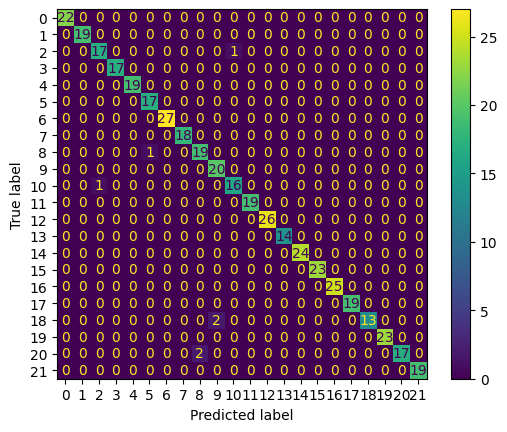

In [ ]:
# Confusion matrix
print(metrics.classification_report(y_test,MLP_y_pred))
confus_matrix = metrics.confusion_matrix(y_test,MLP_y_pred)
metrics.ConfusionMatrixDisplay.from_predictions(y_test,MLP_y_pred)

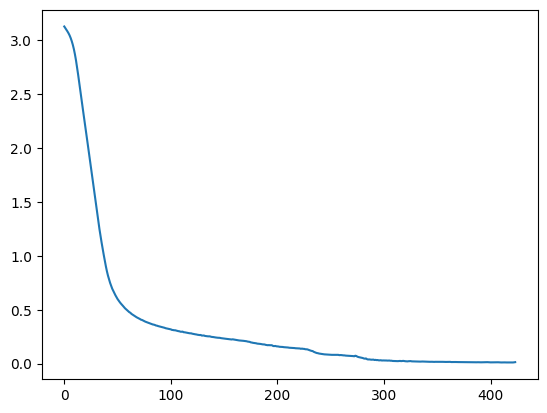

In [ ]:
#Multilayer Perceptron Loss curve
plt.plot(MLP_model.loss_curve_)
plt.show()

In [ ]:
#Using the Grid Search to compare various parameters and identify the best Multiplayer parameter combination
params = {'hidden_layer_sizes' : [(25,18,10,5)], 'activation' : ['relu', 'tanh'], 'solver' : ['adam','sgd'], 'max_iter' : [1000]}

MLmodel = NN.MLPClassifier()
GCV_model = ms.GridSearchCV(MLmodel, param_grid=params, cv=3, n_jobs = -1)
GCV_model.fit(X_train, y_train)
GCV_model.best_params_

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


{'activation': 'tanh',
 'hidden_layer_sizes': (25, 18, 10, 5),
 'max_iter': 1000,
 'solver': 'adam'}

In [ ]:
GCV_y_pred = GCV_model.predict(X_test)
Ml_Acc = metrics.accuracy_score(y_test,GCV_y_pred)
print(Ml_Acc)
Accuracy_.append(Ml_Acc)
model_name.append('MLP')

0.9840909090909091


<ipython-input-45-f85bab0964de>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = Accuracy_[0:2], y = model_name[0:2], palette = 'deep')


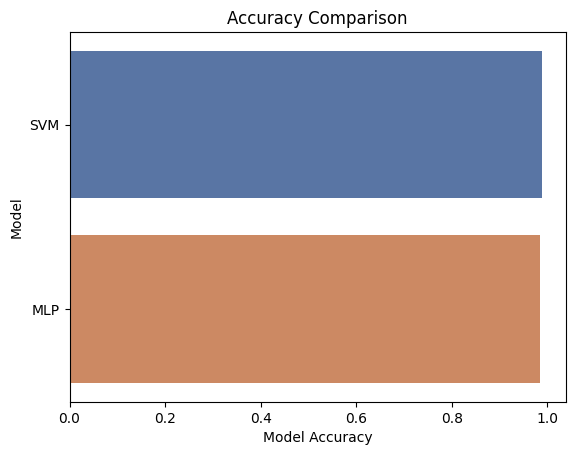

In [ ]:
#Accurcy comparison of SVM and MLP Grid search
sns.barplot(x = Accuracy_[0:2], y = model_name[0:2], palette = 'deep')
plt.title('Accuracy Comparison')
plt.xlabel('Model Accuracy')
plt.ylabel('Model')
plt.show()

# **Question 3, Task 3: Replace the classifier model in your program with a deep convolutional neural network (CNN) with a minimum of 3 convolutional layers using the Keras or TensorFlow library**

In [ ]:
X_trainshp = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_testshp = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
output_classes = 22
X_testshp.shape

(440, 7, 1)

In [ ]:
model = ks.Sequential([
    ks.layers.Conv1D(32, kernel_size = 3, activation = 'tanh', input_shape = (X_train.shape[1], 1), padding = 'same'),
    ks.layers.MaxPooling1D(pool_size = 3, padding = 'same'),
    ks.layers.Conv1D(64,kernel_size = 3, activation = 'tanh', padding = 'same'),
    ks.layers.MaxPooling1D(pool_size = 3, padding = 'same'),
    ks.layers.Conv1D(128,kernel_size = 3, activation = 'tanh', padding = 'same'),
    ks.layers.MaxPooling1D(pool_size = 3, padding = 'same'),
    ks.layers.Dropout(0.2),
    ks.layers.Flatten(),
    ks.layers.Dense(128, activation='tanh'),
    ks.layers.Dense(output_classes, activation = 'softmax')
])

model.compile(optimizer='adam',
              loss=ks.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

## Train the model
model.fit(X_trainshp, y_train, epochs=50, batch_size=128)
model.save('crop_recommendation_cnnmodel.keras')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 7, 32)             128       
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 3, 32)             0         
 g1D)                                                            
                                                                 
 conv1d_4 (Conv1D)           (None, 3, 64)             6208      
                                                                 
 max_pooling1d_4 (MaxPoolin  (None, 1, 64)             0         
 g1D)                                                            
                                                                 
 conv1d_5 (Conv1D)           (None, 1, 128)            24704     
                                                                 
 max_pooling1d_5 (MaxPoolin  (None, 1, 128)            0

/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5727: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


14/14 [==============================] - 4s 14ms/step - loss: 2.9010 - accuracy: 0.1659
Epoch 2/50
14/14 [==============================] - 0s 12ms/step - loss: 2.4031 - accuracy: 0.3153
Epoch 3/50
14/14 [==============================] - 0s 11ms/step - loss: 1.8239 - accuracy: 0.5716
Epoch 4/50
14/14 [==============================] - 0s 10ms/step - loss: 1.2728 - accuracy: 0.7489
Epoch 5/50
14/14 [==============================] - 0s 12ms/step - loss: 0.8634 - accuracy: 0.8205
Epoch 6/50
14/14 [==============================] - 0s 14ms/step - loss: 0.5915 - accuracy: 0.8705
Epoch 7/50
14/14 [==============================] - 0s 12ms/step - loss: 0.4394 - accuracy: 0.9074
Epoch 8/50
14/14 [==============================] - 0s 12ms/step - loss: 0.3402 - accuracy: 0.9227
Epoch 9/50
14/14 [==============================] - 0s 10ms/step - loss: 0.2776 - accuracy: 0.9386
Epoch 10/50
14/14 [==============================] - 0s 10ms/step - loss: 0.2289 - accuracy: 0.9494
Epoch 11/50
14/14 [=

In [ ]:
## Evaluate the trained model
test_loss, test_acc = model.evaluate(X_testshp,  y_test, verbose=2)
print('\n Test Accuracy:', test_acc)
print('\n Test Loss:', test_loss)
Accuracy_.append(test_acc)
model_name.append('CNN')

14/14 - 0s - loss: 0.0546 - accuracy: 0.9841 - 129ms/epoch - 9ms/step

 Test Accuracy: 0.9840909242630005

 Test Loss: 0.05462130159139633


<ipython-input-47-391357727ddf>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = Accuracy_, y = model_name, palette = 'deep' )


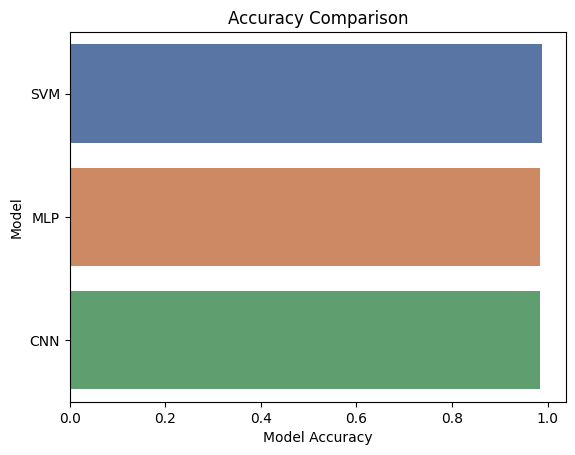

In [ ]:
#Accurcy comparison of SVM, MLP and CNN
sns.barplot(x = Accuracy_, y = model_name, palette = 'deep' )
plt.title('Accuracy Comparison')
plt.xlabel('Model Accuracy')
plt.ylabel('Model')
plt.show()

# **Question 3, Task 4: Use a clustering method of your choice to cluster the dataset, and measure how accurately the clusters correspond to the classes in your dataset. Determine the optimum number of clusters**

In [ ]:
X

array([[ 1.0687974 , -0.34455075, -0.1016875 , ...,  0.47266646,
         0.04330173,  1.8103605 ],
       [ 0.93332887,  0.14061552, -0.14118477, ...,  0.39705125,
         0.73487256,  2.24205791],
       [ 0.25598625,  0.04964684, -0.08193887, ...,  0.48695381,
         1.77151047,  2.92106603],
       ...,
       [ 1.82742114, -0.61745677, -0.35841972, ..., -0.19123516,
        -0.13812031,  1.27141766],
       [ 1.80032743, -0.64777967, -0.27942519, ..., -0.86951801,
         0.37390383,  0.43154519],
       [ 1.44810927, -1.07230015, -0.35841972, ..., -0.49802006,
         0.40109573,  0.68200518]])

In [ ]:
Clust_SumOfSquare = []
number_clusters = range(2,22)
for i in number_clusters:
    kmeans = KMeans(i, init = 'k-means++', n_init = 10)
    kmeans.fit(X)
    Km_Inertia = kmeans.inertia_
    Clust_SumOfSquare.append(Km_Inertia)

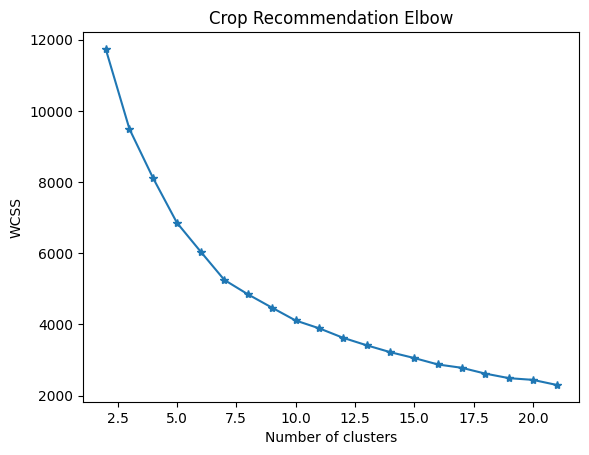

In [ ]:
plt.plot(number_clusters,Clust_SumOfSquare, '*-')
plt.title('Crop Recommendation Elbow')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
Silhouette_sc = []
number_clusters = range(2,22)
for i in number_clusters:
    kmeans = KMeans(i, init = 'k-means++', n_init = 10)
    kmeans.fit(X)
    Labels_ = kmeans.labels_
    scores = metrics.silhouette_score(X,Labels_)
    #Using Adjusted Rand score to measure how well the clusters respond to classes in the dataset
    ars = metrics.adjusted_rand_score(y, Labels_)
    print("Adjusted Rand Index is ", ars, " when the number of cluster is ", i, " Silhoutte_score is ", scores)
    Silhouette_sc.append(scores)

Adjusted Rand Index is  0.01850774310691727  when the number of cluster is  2  Silhoutte_score is  0.4168458131187345
Adjusted Rand Index is  0.10583870396020413  when the number of cluster is  3  Silhoutte_score is  0.2518637956538092
Adjusted Rand Index is  0.18563165082852057  when the number of cluster is  4  Silhoutte_score is  0.25526916389002857
Adjusted Rand Index is  0.23216702602258543  when the number of cluster is  5  Silhoutte_score is  0.29246003667482134
Adjusted Rand Index is  0.26475750245318735  when the number of cluster is  6  Silhoutte_score is  0.3045152753934814
Adjusted Rand Index is  0.33814672685664  when the number of cluster is  7  Silhoutte_score is  0.3332518760723474
Adjusted Rand Index is  0.3958343360623  when the number of cluster is  8  Silhoutte_score is  0.3265725788326684
Adjusted Rand Index is  0.40512292462986493  when the number of cluster is  9  Silhoutte_score is  0.3320847349098888
Adjusted Rand Index is  0.4388188990915656  when the number o

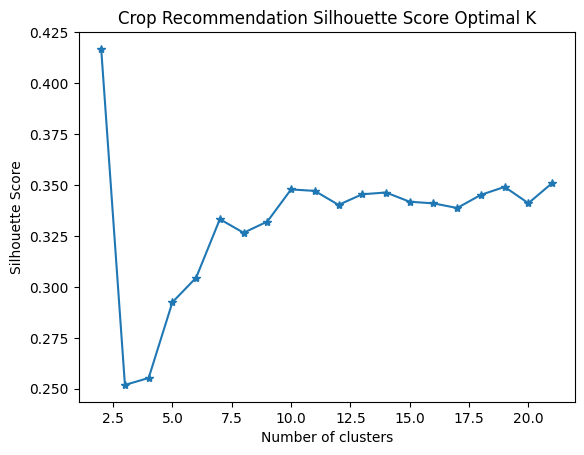

In [ ]:
plt.plot(number_clusters,Silhouette_sc, '*-')
plt.title('Crop Recommendation Silhouette Score Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()